# Combined Dataset - Inception + Add (Our Method)

**Inception cells fused with Add (your approach) — no skip | All 24 classes**

Dataset: 24 classes

> Run on Kaggle / Colab with GPU


In [1]:
!pip install kaggle tensorflow scikit-learn matplotlib seaborn pandas numpy Pillow tqdm psutil -q
print('Packages ready.')


Packages ready.


In [2]:
import os, math, random, json, warnings, zipfile, shutil, time, tracemalloc, psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import defaultdict
from matplotlib.patches import Patch
from itertools import cycle
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D,
    Flatten, Dense, Dropout, Add, Concatenate, Layer, AveragePooling2D
)
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)
print(f'TF {tf.__version__}  |  GPUs: {len(gpus)}')


2026-04-23 09:30:11.147226: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776936611.320360      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776936611.370779      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776936611.785077      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776936611.785120      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776936611.785123      55 computation_placer.cc:177] computation placer alr

TF 2.19.0  |  GPUs: 2


In [3]:
KAGGLE_USERNAME = "jyotiradityachillal"
KAGGLE_KEY      = "KGAT_bba51b5487bd42a6dc26ac9524d520f9"
import os, json as _j
kd = os.path.expanduser("~/.kaggle")
os.makedirs(kd, exist_ok=True)
with open(os.path.join(kd,"kaggle.json"),"w") as f:
    _j.dump({"username":KAGGLE_USERNAME,"key":KAGGLE_KEY}, f)
os.chmod(os.path.join(kd,"kaggle.json"), 0o600)
os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
os.environ["KAGGLE_KEY"]      = KAGGLE_KEY
print("Kaggle credentials set.")


Kaggle credentials set.


In [4]:
NOTEBOOK_ID  = "NB6_Combined_InceptionAdd"
SEED         = 42
IMG_SIZE     = (256, 256)
IMG_SHAPE    = (256, 256, 3)
BATCH_SIZE   = 64
INITIAL_LR   = 1e-3
EPOCHS       = 50
DROPOUT_RATE = 0.5

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

TARGET_CLASSES  = ['Cotton_Aphids', 'Cotton_Army_worm', 'Cotton_Bacterial_Blight', 'Cotton_Healthy', 'Cotton_Powdery_mildew', 'Cotton_Target_Spot', 'Wheat_Brown_rust', 'Wheat_Healthy', 'Wheat_Yellow_rust', 'Potato_Early_blight', 'Potato_Late_blight', 'Potato_Healthy', 'Bell_Pepper_Bacterial_spot', 'Bell_Pepper_Healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites', 'Tomato_Target_spot', 'Tomato_Yellowleaf_curl_virus', 'Tomato_Mosaic_virus', 'Tomato_Healthy']
NUM_CLASSES     = len(TARGET_CLASSES)
CLASS_TO_IDX    = {cls:i for i,cls in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS    = {i:cls for i,cls in enumerate(TARGET_CLASSES)}
TARGET_COUNTS   = {'Cotton_Aphids': 800, 'Cotton_Army_worm': 800, 'Cotton_Bacterial_Blight': 800, 'Cotton_Healthy': 800, 'Cotton_Powdery_mildew': 800, 'Cotton_Target_Spot': 788, 'Wheat_Brown_rust': 902, 'Wheat_Healthy': 1116, 'Wheat_Yellow_rust': 924, 'Potato_Early_blight': 1000, 'Potato_Late_blight': 1000, 'Potato_Healthy': 152, 'Bell_Pepper_Bacterial_spot': 997, 'Bell_Pepper_Healthy': 1478, 'Tomato_Bacterial_spot': 2127, 'Tomato_Early_blight': 1000, 'Tomato_Late_blight': 1909, 'Tomato_Leaf_mold': 952, 'Tomato_Septoria_leaf_spot': 1771, 'Tomato_Spider_mites': 1676, 'Tomato_Target_spot': 1404, 'Tomato_Yellowleaf_curl_virus': 3209, 'Tomato_Mosaic_virus': 373, 'Tomato_Healthy': 1591}
KAGGLE_DATASETS = [('mohitsingh1804/plantvillage', 'plantvillage'), ('dhamur/cotton-plant-disease', 'cotton-plant-disease'), ('sinadunk23/behzad-safari-jalal', 'behzad-safari-jalal')]
VALID_EXTS      = {'.jpg','.jpeg','.png','.bmp','.tif','.tiff'}

BASE_DIR    = os.path.join(os.path.expanduser('~'), 'plant_project', NOTEBOOK_ID)
RAW_DIR     = os.path.join(os.path.expanduser('~'), 'plant_project', 'raw')
UNIFIED_DIR = os.path.join(BASE_DIR, 'unified')
CKPT_DIR    = os.path.join(BASE_DIR, 'checkpoints')
LOG_DIR     = os.path.join(BASE_DIR, 'logs')
for d in [BASE_DIR,RAW_DIR,UNIFIED_DIR,CKPT_DIR,LOG_DIR]:
    os.makedirs(d, exist_ok=True)

def get_images(folder):
    if not os.path.isdir(folder): return []
    return [os.path.join(folder,f) for f in os.listdir(folder)
            if os.path.splitext(f)[1].lower() in VALID_EXTS]

print(f'Notebook  : {NOTEBOOK_ID}')
print(f'Classes   : {NUM_CLASSES}')
print(f'Base dir  : {BASE_DIR}')


Notebook  : NB6_Combined_InceptionAdd
Classes   : 24
Base dir  : /root/plant_project/NB6_Combined_InceptionAdd


In [5]:
orig_dir = os.getcwd(); os.chdir(RAW_DIR)
for ds_slug, folder_name in KAGGLE_DATASETS:
    tf = os.path.join(RAW_DIR, folder_name)
    zf = os.path.join(RAW_DIR, folder_name+'.zip')
    if os.path.isdir(tf) and os.listdir(tf):
        print(f'  Ready: {folder_name}/'); continue
    if not os.path.isfile(zf):
        print(f'Downloading {ds_slug}...')
        os.system(f'kaggle datasets download -d {ds_slug} --quiet')
    print(f'Extracting {folder_name}...')
    import zipfile as _zf
    with _zf.ZipFile(zf,'r') as z: z.extractall(tf)
    print(f'  Done')
os.chdir(orig_dir)
print('Datasets ready.')


Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage
License(s): GPL-2.0
Extracting plantvillage...
  Done
Dataset URL: https://www.kaggle.com/datasets/dhamur/cotton-plant-disease
License(s): ODbL-1.0
Extracting cotton-plant-disease...
  Done
Dataset URL: https://www.kaggle.com/datasets/sinadunk23/behzad-safari-jalal
License(s): unknown
Extracting behzad-safari-jalal...
  Done
Datasets ready.


In [6]:
FOLDER_MAP = {
    'aphids':'Cotton_Aphids','aphid':'Cotton_Aphids',
    'army worm':'Cotton_Army_worm','army_worm':'Cotton_Army_worm','armyworm':'Cotton_Army_worm',
    'bacterial blight':'Cotton_Bacterial_Blight','bacterial_blight':'Cotton_Bacterial_Blight',
    'powdery mildew':'Cotton_Powdery_mildew','powdery_mildew':'Cotton_Powdery_mildew','powderymildew':'Cotton_Powdery_mildew',
    'target spot':'Cotton_Target_Spot','target_spot':'Cotton_Target_Spot',
    'pepper,_bell___bacterial_spot':'Bell_Pepper_Bacterial_spot',
    'pepper___bacterial_spot':'Bell_Pepper_Bacterial_spot',
    'bell_pepper___bacterial_spot':'Bell_Pepper_Bacterial_spot',
    'pepper,_bell___healthy':'Bell_Pepper_Healthy',
    'pepper___healthy':'Bell_Pepper_Healthy',
    'bell_pepper___healthy':'Bell_Pepper_Healthy',
    'potato___early_blight':'Potato_Early_blight',
    'potato___late_blight':'Potato_Late_blight',
    'potato___healthy':'Potato_Healthy',
    'tomato___bacterial_spot':'Tomato_Bacterial_spot',
    'tomato___early_blight':'Tomato_Early_blight',
    'tomato___late_blight':'Tomato_Late_blight',
    'tomato___leaf_mold':'Tomato_Leaf_mold',
    'tomato___septoria_leaf_spot':'Tomato_Septoria_leaf_spot',
    'tomato___spider_mites two-spotted_spider_mite':'Tomato_Spider_mites',
    'tomato___spider_mites_two-spotted_spider_mite':'Tomato_Spider_mites',
    'tomato___spider_mites':'Tomato_Spider_mites',
    'tomato___target_spot':'Tomato_Target_spot',
    'tomato___tomato_yellow_leaf_curl_virus':'Tomato_Yellowleaf_curl_virus',
    'tomato___tomato_mosaic_virus':'Tomato_Mosaic_virus',
    'tomato___healthy':'Tomato_Healthy',
    'brown rust':'Wheat_Brown_rust','brown_rust':'Wheat_Brown_rust','brownrust':'Wheat_Brown_rust',
    'yellow rust':'Wheat_Yellow_rust','yellow_rust':'Wheat_Yellow_rust','yellowrust':'Wheat_Yellow_rust',
}
HEALTHY_CONTEXT = {'cotton':'Cotton_Healthy','wheat':'Wheat_Healthy','potato':'Potato_Healthy'}

def resolve_class(folder_path):
    name = os.path.basename(folder_path).lower().strip()
    if name in FOLDER_MAP: return FOLDER_MAP[name]
    if name in ('healthy','normal','disease free'):
        fl = folder_path.lower()
        for k,v in HEALTHY_CONTEXT.items():
            if k in fl: return v
    return None

print('Folder map ready.')


Folder map ready.


In [7]:
class_files = defaultdict(list)
for _, folder in KAGGLE_DATASETS:
    ds_root = os.path.join(RAW_DIR, folder)
    if not os.path.isdir(ds_root): continue
    for dirpath, _, filenames in os.walk(ds_root):
        imgs = [f for f in filenames if os.path.splitext(f)[1].lower() in VALID_EXTS]
        if not imgs: continue
        cls = resolve_class(dirpath)
        if cls and cls in TARGET_CLASSES:
            class_files[cls].extend([os.path.join(dirpath,f) for f in imgs])

print('Scan done:')
for cls in TARGET_CLASSES:
    print(f'  {cls:<40} {len(class_files[cls]):>5}')

# Build unified
random.seed(SEED); actual_counts = {}
for cls in TARGET_CLASSES:
    cls_dir = os.path.join(UNIFIED_DIR, cls)
    os.makedirs(cls_dir, exist_ok=True)
    ex = get_images(cls_dir)
    if ex: actual_counts[cls]=len(ex); continue
    srcs = class_files[cls][:]
    random.shuffle(srcs)
    srcs = srcs[:TARGET_COUNTS.get(cls, 999999)]
    for i,src in enumerate(srcs):
        ext = os.path.splitext(src)[1].lower() or '.jpg'
        dst = os.path.join(cls_dir, f'{i:05d}{ext}')
        if not os.path.exists(dst): shutil.copy2(src, dst)
    actual_counts[cls] = len(srcs)

total = sum(actual_counts.values())
print(f'\nUnified: {total:,} images across {NUM_CLASSES} classes')


Scan done:
  Cotton_Aphids                             4320
  Cotton_Army_worm                          4320
  Cotton_Bacterial_Blight                   4320
  Cotton_Healthy                            4320
  Cotton_Powdery_mildew                     4320
  Cotton_Target_Spot                        4271
  Wheat_Brown_rust                          1128
  Wheat_Healthy                                0
  Wheat_Yellow_rust                         1156
  Potato_Early_blight                       1000
  Potato_Late_blight                        1000
  Potato_Healthy                             152
  Bell_Pepper_Bacterial_spot                 997
  Bell_Pepper_Healthy                       1478
  Tomato_Bacterial_spot                     2127
  Tomato_Early_blight                       1000
  Tomato_Late_blight                        1909
  Tomato_Leaf_mold                           952
  Tomato_Septoria_leaf_spot                 1771
  Tomato_Spider_mites                       1676
  Tomato_

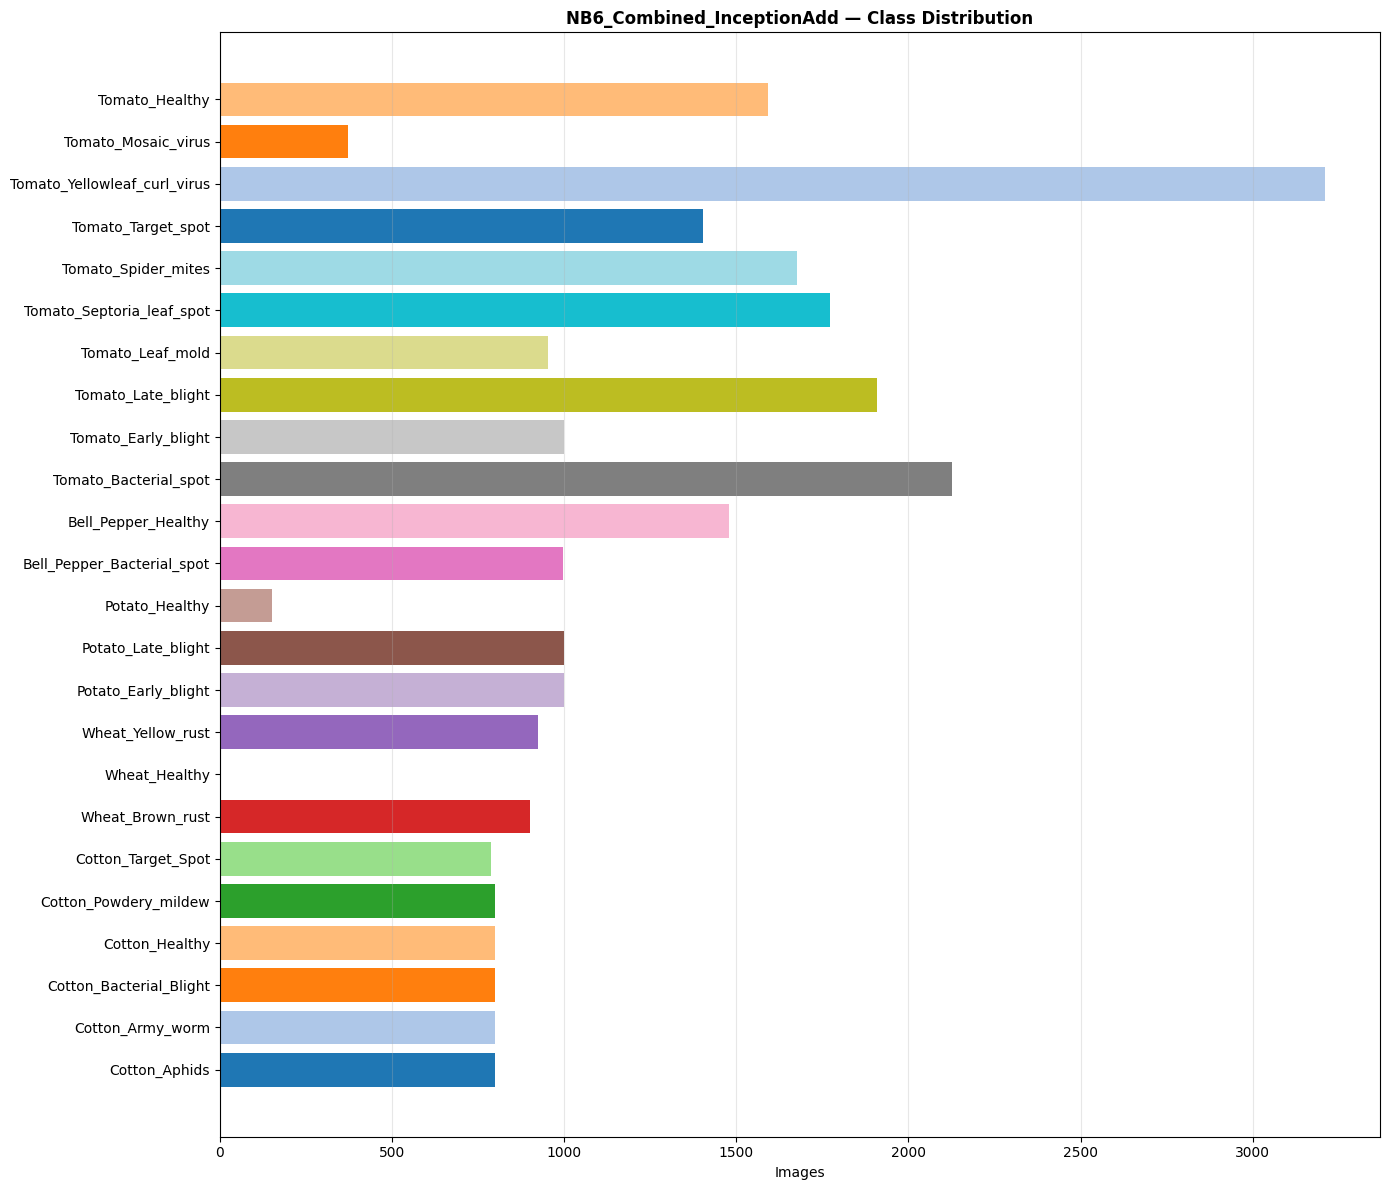

Total images: 27,253


In [8]:
all_paths, all_labels = [], []
for cls in TARGET_CLASSES:
    imgs = get_images(os.path.join(UNIFIED_DIR, cls))
    all_paths.extend(imgs); all_labels.extend([CLASS_TO_IDX[cls]]*len(imgs))
all_paths  = np.array(all_paths)
all_labels = np.array(all_labels, dtype=np.int32)

counts = [len(get_images(os.path.join(UNIFIED_DIR,c))) for c in TARGET_CLASSES]
fig,ax = plt.subplots(figsize=(14,max(4,NUM_CLASSES//2)))
colors = plt.cm.tab20.colors
ax.barh(TARGET_CLASSES, counts, color=[colors[i%20] for i in range(NUM_CLASSES)])
ax.set_xlabel('Images'); ax.set_title(f'{NOTEBOOK_ID} — Class Distribution',fontweight='bold')
ax.grid(True,axis='x',alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,'eda_distribution.png'),dpi=120,bbox_inches='tight')
plt.show()
print(f'Total images: {sum(counts):,}')


In [9]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    all_paths, all_labels, test_size=0.30, random_state=SEED, stratify=all_labels)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)
print(f'Train {len(X_tr):,}  Val {len(X_val):,}  Test {len(X_te):,}')


Train 19,077  Val 4,088  Test 4,088


In [10]:
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

def load_img(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32)/255.0, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.85, 1.15)
    img = tf.image.random_hue(img, 0.05)
    return tf.clip_by_value(img,0.0,1.0), label

def make_ds(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training: ds = ds.shuffle(min(len(paths),8000), seed=SEED)
    ds = ds.map(load_img, num_parallel_calls=AUTOTUNE)
    if training: ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(X_tr,  y_tr,  training=True)
val_ds   = make_ds(X_val, y_val)
test_ds  = make_ds(X_te,  y_te)
print('tf.data pipelines ready.')


I0000 00:00:1776936726.244498      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776936726.251049      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


tf.data pipelines ready.


In [11]:
class CosineAnnealingScheduler(LearningRateScheduler):
    def __init__(self, initial_lr, total_epochs):
        self.initial_lr = initial_lr
        self.total_epochs = total_epochs
        super().__init__(self._sched, verbose=0)
    def _sched(self, epoch, lr):
        return 0.5*self.initial_lr*(1+math.cos(math.pi*epoch/self.total_epochs))
    def get_config(self):
        cfg = super().get_config()
        cfg.update({'initial_lr':self.initial_lr,'total_epochs':self.total_epochs})
        return cfg

print('CosineAnnealingScheduler defined.')


CosineAnnealingScheduler defined.


In [12]:
class Inception_cell(Layer):
    def __init__(self, num_filters, activation='relu', padding='same', **kwargs):
        super().__init__(**kwargs)
        self.num_filters=num_filters; self.activation=activation; self.padding=padding
        self.conv3 = Conv2D(num_filters,(3,3),activation=activation,padding=padding)
        self.conv5 = Conv2D(num_filters,(5,5),activation=activation,padding=padding)
        self.conv7 = Conv2D(num_filters,(7,7),activation=activation,padding=padding)
    def call(self,x,training=False): return Add()([self.conv3(x),self.conv5(x),self.conv7(x)])
    def get_config(self):
        cfg=super().get_config(); cfg.update({'num_filters':self.num_filters,'activation':self.activation,'padding':self.padding}); return cfg

class SkipConnection(Layer):
    def __init__(self,num_filters,kernel_size=7,activation='relu',padding='same',**kwargs):
        super().__init__(**kwargs)
        self.num_filters=num_filters; self.kernel_size=kernel_size
        self.activation=activation; self.padding=padding
        self.conv=Conv2D(num_filters,(7,7),activation=activation,padding=padding)
        self.bn=BatchNormalization()
    def call(self,x,training=False):
        out=self.conv(x); out=self.bn(out,training=training)
        return Concatenate(axis=-1)([out,x])
    def get_config(self):
        cfg=super().get_config(); cfg.update({'num_filters':self.num_filters,'kernel_size':self.kernel_size,'activation':self.activation,'padding':self.padding}); return cfg

print('Custom layers defined: Inception_cell (Add) + SkipConnection (Concat)')


Custom layers defined: Inception_cell (Add) + SkipConnection (Concat)


In [13]:
# Inception with Add only — same as your Inception_cell but deeper, no skip conn

def build_model():
    inp = Input(shape=IMG_SHAPE)
    x = Inception_cell(16, name='inc1')(inp)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Inception_cell(32, name='inc2')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Inception_cell(64, name='inc3')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Inception_cell(128, name='inc4')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256,activation='relu')(x)
    x = Dropout(DROPOUT_RATE)(x)
    x = Dense(64,activation='relu')(x)
    out = Dense(NUM_CLASSES,activation='softmax')(x)
    return Model(inp,out,name='InceptionAdd')

model = build_model()
model.summary()
print('Architecture: Inception cells with Add fusion only (no skip connections, GAP head)')


Model: "InceptionAdd"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc1 (Inception_cell)           │ (None, 256, 256, 16)   │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc2 (Inception_cell)           │ (None, 128, 128, 32)   │        42,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc3 (Inception_cell)           │ (None, 64, 64, 64)     │       170,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc4 (Inception_cell)           │ (None, 32, 32, 128)    │       680,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 949,112 (3.62 MB)

 Trainable params: 948,632 (3.62 MB)

 Non-trainable params: 480 (1.88 KB)

Architecture: Inception cells with Add fusion only (no skip connections, GAP head)


In [14]:
ckpt_path = os.path.join(CKPT_DIR,'best.weights.h5')
callbacks = [
    CosineAnnealingScheduler(INITIAL_LR, EPOCHS),
    ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True,
                    save_weights_only=True, verbose=0),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
]

model.compile(optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

tracemalloc.start()
t0 = time.time()
history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds,
                    callbacks=callbacks, verbose=1)
train_time = time.time()-t0
_, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()
ram_used_mb = psutil.Process().memory_info().rss / 1e6

print(f'\nTraining time : {train_time/60:.1f} min')
print(f'Peak memory   : {peak_mem/1e6:.1f} MB')
print(f'RAM used      : {ram_used_mb:.1f} MB')
print(f'Total params  : {model.count_params():,}')


Model: "InceptionAdd"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc1 (Inception_cell)           │ (None, 256, 256, 16)   │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc2 (Inception_cell)           │ (None, 128, 128, 32)   │        42,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc3 (Inception_cell)           │ (None, 64, 64, 64)     │       170,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc4 (Inception_cell)           │ (None, 32, 32, 128)    │       680,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 949,112 (3.62 MB)

 Trainable params: 948,632 (3.62 MB)

 Non-trainable params: 480 (1.88 KB)

Epoch 1/50


I0000 00:00:1776936745.743598     123 service.cc:152] XLA service 0x7b109c226610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776936745.743649     123 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776936745.743655     123 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776936747.129382     123 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-23 09:32:38.969992: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 09:32:39.126376: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 09:32:40.185632: E external/local_xl

298/299 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.2843 - loss: 2.3866

2026-04-23 09:34:36.900962: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 09:34:37.043804: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 09:34:37.750435: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 09:34:38.038076: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


299/299 ━━━━━━━━━━━━━━━━━━━━ 176s 423ms/step - accuracy: 0.2850 - loss: 2.3839 - val_accuracy: 0.2361 - val_loss: 3.8321 - learning_rate: 0.0010
Epoch 2/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 97s 325ms/step - accuracy: 0.5339 - loss: 1.4029 - val_accuracy: 0.6536 - val_loss: 0.9628 - learning_rate: 9.9901e-04
Epoch 3/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 97s 324ms/step - accuracy: 0.6062 - loss: 1.1508 - val_accuracy: 0.6074 - val_loss: 1.0855 - learning_rate: 9.9606e-04
Epoch 4/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 97s 324ms/step - accuracy: 0.6712 - loss: 0.9509 - val_accuracy: 0.6793 - val_loss: 0.8978 - learning_rate: 9.9114e-04
Epoch 5/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 97s 324ms/step - accuracy: 0.6869 - loss: 0.8832 - val_accuracy: 0.4902 - val_loss: 1.7671 - learning_rate: 9.8429e-04
Epoch 6/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 97s 324ms/step - accuracy: 0.7129 - loss: 0.8025 - val_accuracy: 0.6666 - val_loss: 0.9994 - learning_rate: 9.7553e-04
Epoch 7/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 97s 324ms/step - acc

Training history saved: /root/plant_project/NB6_Combined_InceptionAdd/logs/training_history.csv


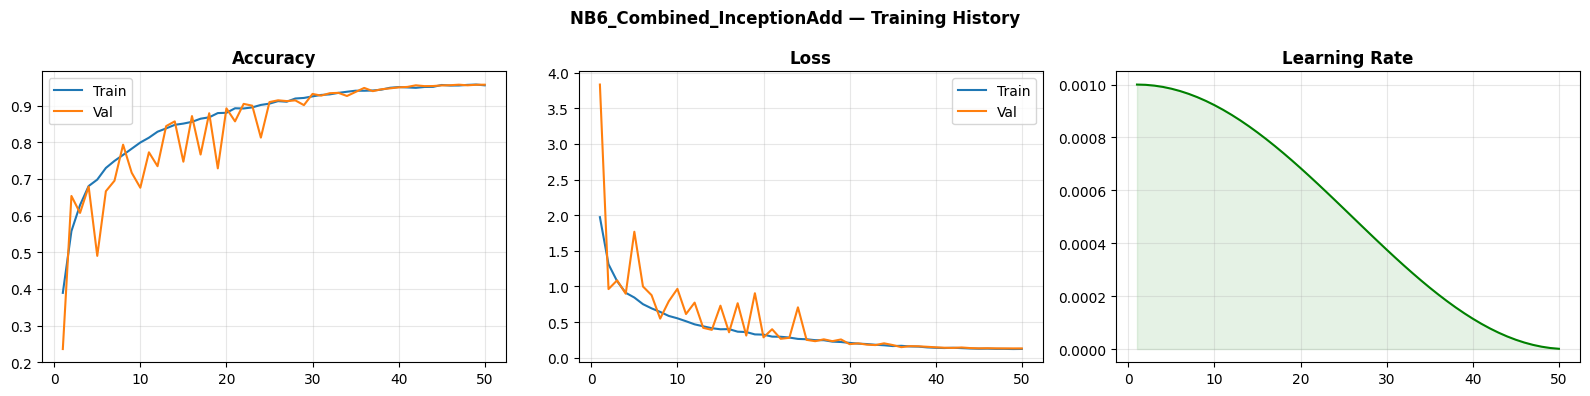

In [15]:
hist = history.history
hist_df = pd.DataFrame(hist)
hist_df['epoch'] = range(1, len(hist_df)+1)
hist_df['notebook'] = NOTEBOOK_ID
hist_df['train_time_sec'] = train_time
hist_df['peak_mem_mb']    = peak_mem/1e6
hist_df['total_params']   = model.count_params()
csv_path = os.path.join(LOG_DIR,'training_history.csv')
hist_df.to_csv(csv_path, index=False)
print(f'Training history saved: {csv_path}')

# Plot curves
fig,axes = plt.subplots(1,3,figsize=(16,4))
n_ep = range(1,len(hist['loss'])+1)
axes[0].plot(n_ep,hist['accuracy'],label='Train'); axes[0].plot(n_ep,hist['val_accuracy'],label='Val')
axes[0].set_title('Accuracy',fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(n_ep,hist['loss'],label='Train'); axes[1].plot(n_ep,hist['val_loss'],label='Val')
axes[1].set_title('Loss',fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)
lrs=[0.5*INITIAL_LR*(1+math.cos(math.pi*e/EPOCHS)) for e in range(len(hist['loss']))]
axes[2].plot(n_ep,lrs,color='green'); axes[2].fill_between(n_ep,lrs,alpha=0.1,color='green')
axes[2].set_title('Learning Rate',fontweight='bold'); axes[2].grid(alpha=0.3)
fig.suptitle(f'{NOTEBOOK_ID} — Training History',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,'training_curves.png'),dpi=120,bbox_inches='tight')
plt.show()


In [16]:
if os.path.exists(ckpt_path): model.load_weights(ckpt_path)
y_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.concatenate([y for _,y in test_ds])[:len(y_pred)]

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

# Per-class sensitivity (recall)
report_dict = classification_report(y_true, y_pred,labels=list(range(len(TARGET_CLASSES))), target_names=TARGET_CLASSES,
                                     output_dict=True, zero_division=0)
sensitivity = {cls: report_dict[cls]['recall'] for cls in TARGET_CLASSES}
specificity_list = []
for i,cls in enumerate(TARGET_CLASSES):
    tp = np.sum((y_true==i)&(y_pred==i))
    fp = np.sum((y_true!=i)&(y_pred==i))
    fn = np.sum((y_true==i)&(y_pred!=i))
    tn = np.sum((y_true!=i)&(y_pred!=i))
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    specificity_list.append(spec)
mean_specificity = np.mean(specificity_list)

print('='*52)
print(f'  Accuracy    : {acc:.4f}')
print(f'  Precision   : {prec:.4f}')
print(f'  Recall      : {rec:.4f}')
print(f'  F1-Score    : {f1:.4f}')
print(f'  Specificity : {mean_specificity:.4f}')
print(f'  Params      : {model.count_params():,}')
print(f'  Train time  : {train_time/60:.1f} min')
print(f'  RAM (MB)    : {ram_used_mb:.1f}')
print('='*52)

# Save metrics CSV
metrics_df = pd.DataFrame([{
    'notebook':NOTEBOOK_ID,'accuracy':acc,'precision':prec,'recall':rec,'f1':f1,
    'specificity':mean_specificity,'params':model.count_params(),
    'train_time_min':train_time/60,'ram_mb':ram_used_mb,'peak_mem_mb':peak_mem/1e6,
    'num_classes':NUM_CLASSES,'best_val_acc':max(hist['val_accuracy'])
}])
metrics_df.to_csv(os.path.join(LOG_DIR,'metrics_summary.csv'), index=False)
print('Metrics saved.')


64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step
  Accuracy    : 0.9584
  Precision   : 0.9584
  Recall      : 0.9584
  F1-Score    : 0.9582
  Specificity : 0.9982
  Params      : 949,112
  Train time  : 82.0 min
  RAM (MB)    : 3920.5
Metrics saved.


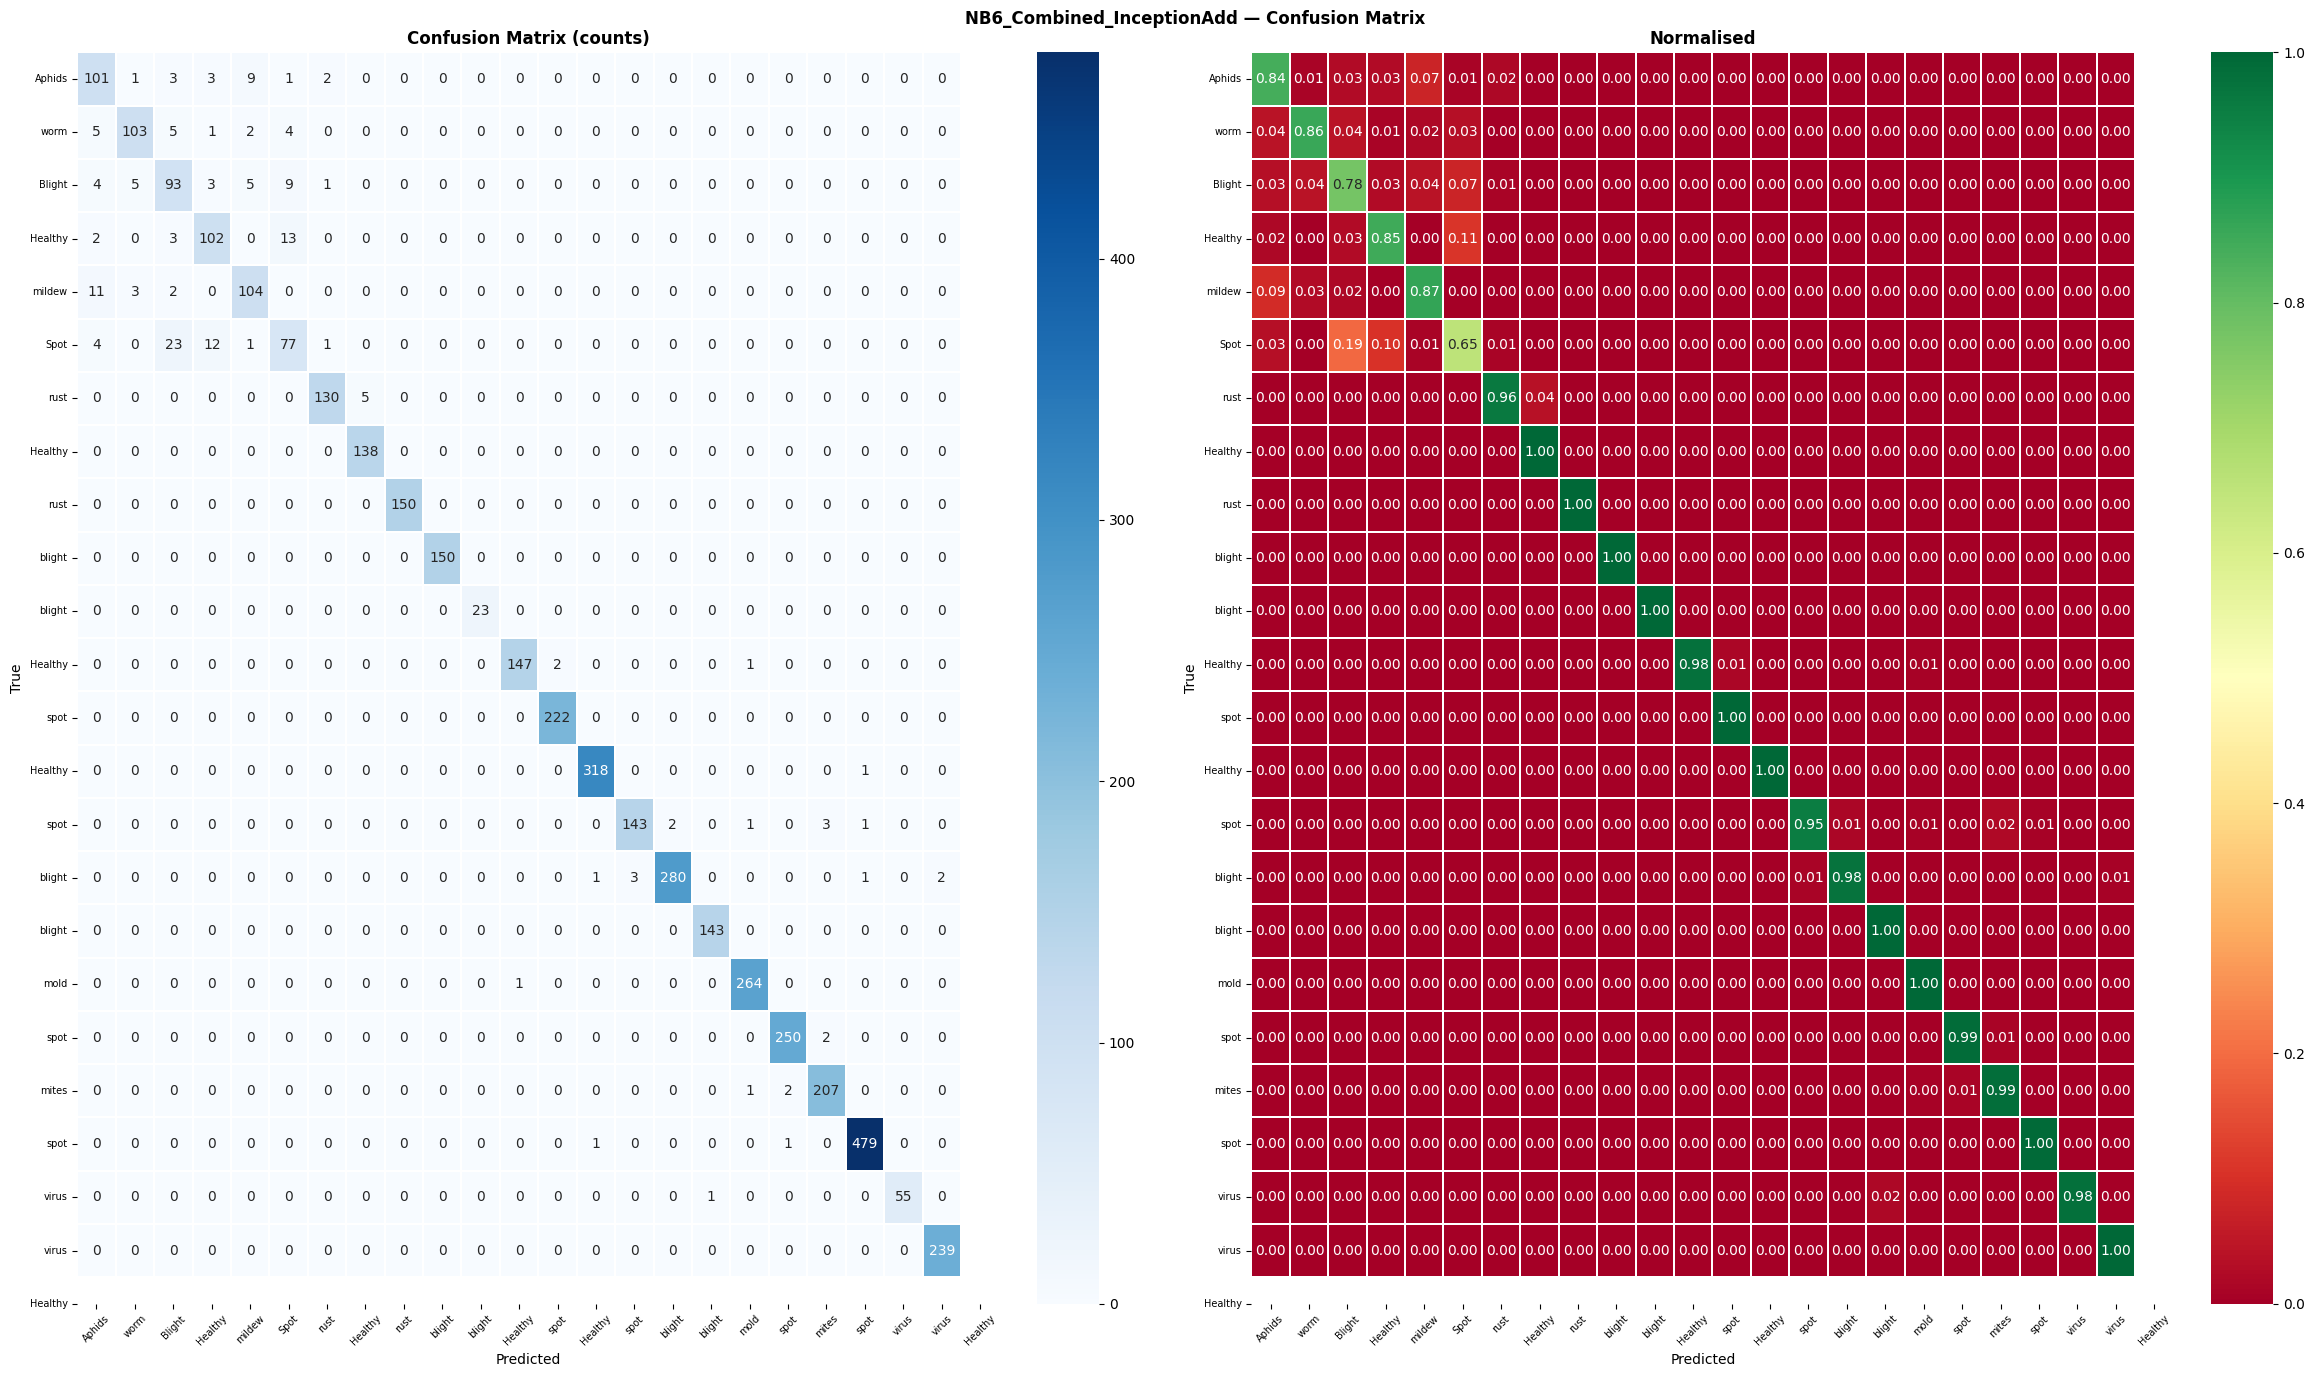

In [17]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float)/cm.sum(axis=1,keepdims=True)
short = [c.split('_')[-1][:10] for c in TARGET_CLASSES]
fig,axes = plt.subplots(1,2,figsize=(max(14,NUM_CLASSES),max(6,NUM_CLASSES//2)+2))
for ax,data,fmt,cmap,title in [
    (axes[0],cm,'d','Blues','Confusion Matrix (counts)'),
    (axes[1],cm_norm,'.2f','RdYlGn','Normalised'),
]:
    sns.heatmap(data,ax=ax,cmap=cmap,fmt=fmt,annot=True,
                xticklabels=short,yticklabels=short,
                linewidths=0.3,linecolor='white',
                **({'vmin':0,'vmax':1} if fmt=='.2f' else {}))
    ax.set_title(title,fontweight='bold'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x',rotation=45,labelsize=7)
    ax.tick_params(axis='y',rotation=0,labelsize=7)
plt.suptitle(f'{NOTEBOOK_ID} — Confusion Matrix',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,'confusion_matrix.png'),dpi=120,bbox_inches='tight')
plt.show()


                              precision    recall  f1-score   support

               Cotton_Aphids     0.7953    0.8417    0.8178       120
            Cotton_Army_worm     0.9196    0.8583    0.8879       120
     Cotton_Bacterial_Blight     0.7209    0.7750    0.7470       120
              Cotton_Healthy     0.8430    0.8500    0.8465       120
       Cotton_Powdery_mildew     0.8595    0.8667    0.8631       120
          Cotton_Target_Spot     0.7404    0.6525    0.6937       118
            Wheat_Brown_rust     0.9701    0.9630    0.9665       135
               Wheat_Healthy     0.0000    0.0000    0.0000         0
           Wheat_Yellow_rust     0.9650    1.0000    0.9822       138
         Potato_Early_blight     1.0000    1.0000    1.0000       150
          Potato_Late_blight     1.0000    1.0000    1.0000       150
              Potato_Healthy     1.0000    1.0000    1.0000        23
  Bell_Pepper_Bacterial_spot     0.9932    0.9800    0.9866       150
         Bell_Peppe

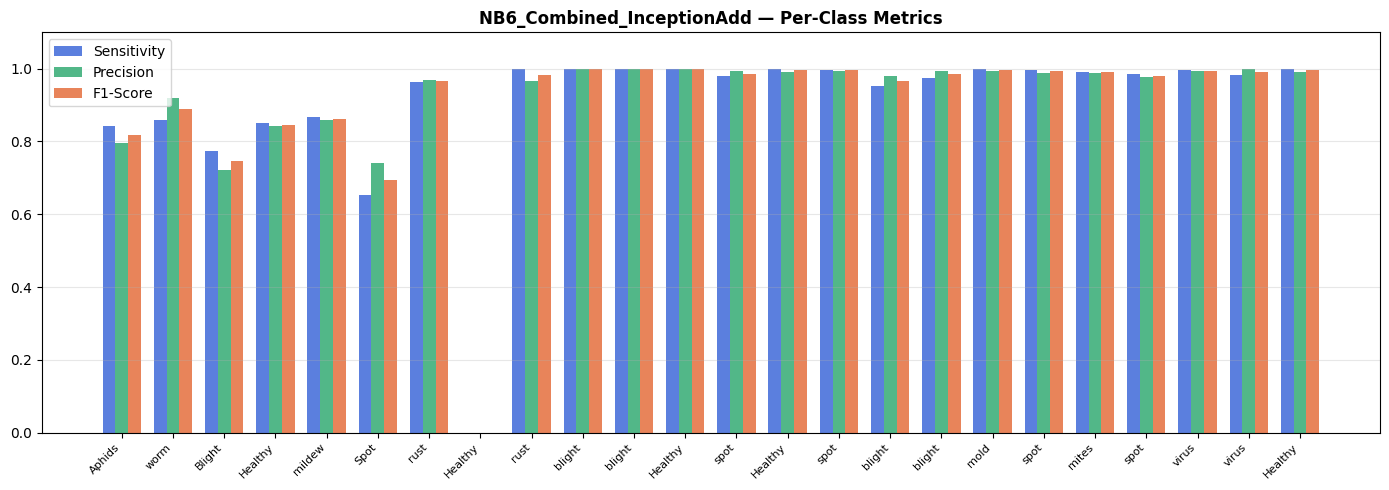

In [18]:
report_str = classification_report(y_true, y_pred,labels=list(range(len(TARGET_CLASSES))), target_names=TARGET_CLASSES,
                                    digits=4, zero_division=0)
print(report_str)
with open(os.path.join(LOG_DIR,'classification_report.txt'),'w') as f:
    f.write(report_str)

per_class_df = pd.DataFrame([{
    'class':cls,'sensitivity':sensitivity[cls],
    'precision':report_dict[cls]['precision'],
    'f1':report_dict[cls]['f1-score'],
    'specificity':specificity_list[i]
} for i,cls in enumerate(TARGET_CLASSES)])
per_class_df.to_csv(os.path.join(LOG_DIR,'per_class_metrics.csv'), index=False)

fig,ax = plt.subplots(figsize=(14,5))
x = np.arange(NUM_CLASSES); w = 0.25
ax.bar(x-w,   per_class_df['sensitivity'], w, label='Sensitivity',color='#5B7FDE')
ax.bar(x,     per_class_df['precision'],   w, label='Precision',  color='#52B788')
ax.bar(x+w,   per_class_df['f1'],          w, label='F1-Score',   color='#E8845A')
ax.set_xticks(x); ax.set_xticklabels([c.split('_')[-1] for c in TARGET_CLASSES],
                                       rotation=45,ha='right',fontsize=8)
ax.set_ylim(0,1.1); ax.legend(); ax.grid(True,axis='y',alpha=0.3)
ax.set_title(f'{NOTEBOOK_ID} — Per-Class Metrics',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,'per_class_metrics.png'),dpi=120,bbox_inches='tight')
plt.show()


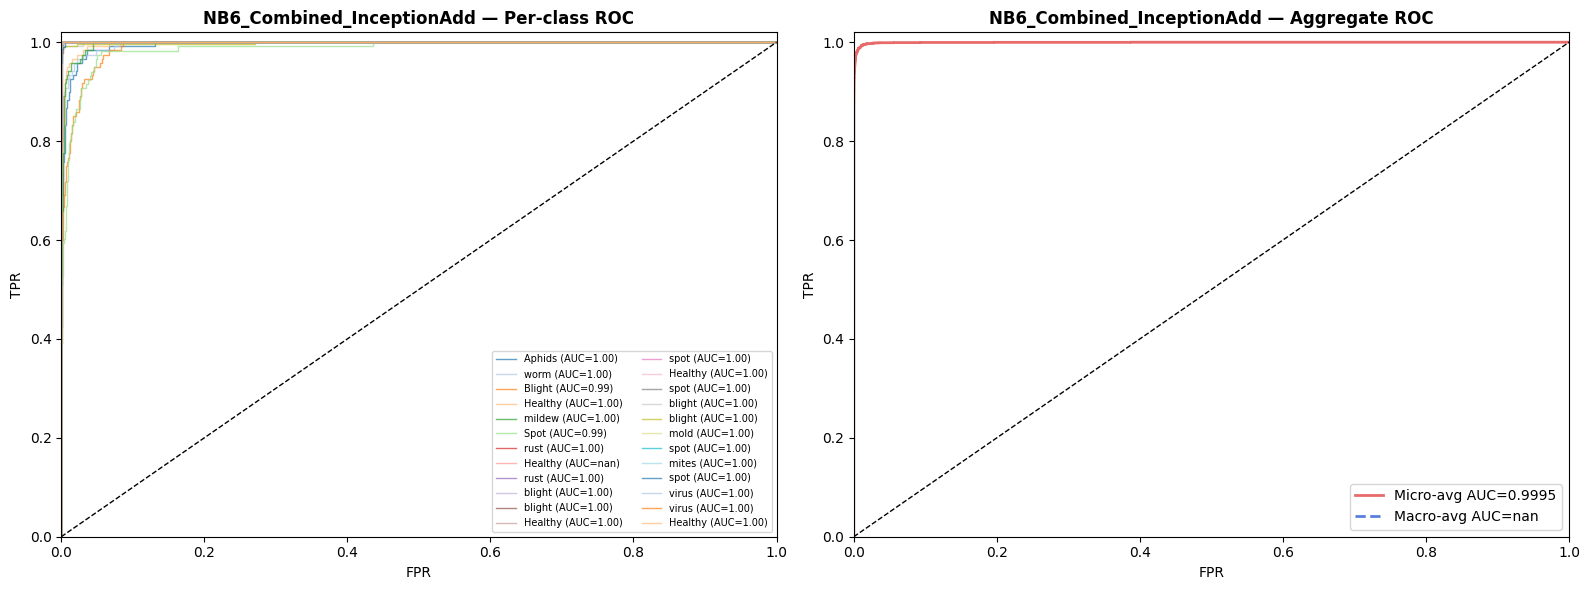

Micro AUC: 0.9995  Macro AUC: nan


In [19]:
y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
fpr_d, tpr_d, roc_auc_d = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr_d[i],tpr_d[i],_ = roc_curve(y_bin[:,i], y_prob[:,i])
    roc_auc_d[i] = auc(fpr_d[i],tpr_d[i])

fpr_d['micro'],tpr_d['micro'],_ = roc_curve(y_bin.ravel(), y_prob.ravel())
roc_auc_d['micro'] = auc(fpr_d['micro'],tpr_d['micro'])

all_fpr = np.unique(np.concatenate([fpr_d[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES): mean_tpr += np.interp(all_fpr,fpr_d[i],tpr_d[i])
mean_tpr /= NUM_CLASSES
fpr_d['macro'],tpr_d['macro'] = all_fpr, mean_tpr
roc_auc_d['macro'] = auc(all_fpr, mean_tpr)

fig,axes = plt.subplots(1,2,figsize=(16,6))
ax = axes[0]
colors = cycle(plt.cm.tab20.colors)
for i,color in zip(range(NUM_CLASSES),colors):
    ax.plot(fpr_d[i],tpr_d[i],color=color,lw=1,alpha=0.7,
            label=f'{TARGET_CLASSES[i].split("_")[-1]} (AUC={roc_auc_d[i]:.2f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'{NOTEBOOK_ID} — Per-class ROC',fontweight='bold')
ax.legend(loc='lower right',fontsize=7,ncol=2)

ax2 = axes[1]
ax2.plot(fpr_d['micro'],tpr_d['micro'],color='#E86B6B',lw=2,
         label=f'Micro-avg AUC={roc_auc_d["micro"]:.4f}')
ax2.plot(fpr_d['macro'],tpr_d['macro'],color='#5B7FDE',lw=2,ls='--',
         label=f'Macro-avg AUC={roc_auc_d["macro"]:.4f}')
ax2.plot([0,1],[0,1],'k--',lw=1); ax2.set_xlim([0,1]); ax2.set_ylim([0,1.02])
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
ax2.set_title(f'{NOTEBOOK_ID} — Aggregate ROC',fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,'roc_curves.png'),dpi=120,bbox_inches='tight')
plt.show()

roc_df = pd.DataFrame({
    'notebook':NOTEBOOK_ID,'class':list(range(NUM_CLASSES))+['micro','macro'],
    'auc':[roc_auc_d[i] for i in range(NUM_CLASSES)]+[roc_auc_d['micro'],roc_auc_d['macro']]
})
roc_df.to_csv(os.path.join(LOG_DIR,'roc_auc.csv'), index=False)

np.save(os.path.join(LOG_DIR,'y_prob.npy'), y_prob)
np.save(os.path.join(LOG_DIR,'y_true.npy'), y_true)
print(f'Micro AUC: {roc_auc_d["micro"]:.4f}  Macro AUC: {roc_auc_d["macro"]:.4f}')


In [20]:
model_path = os.path.join(BASE_DIR,'model.h5')
model.save(model_path)
mapping_path = os.path.join(BASE_DIR,'class_mapping.json')
with open(mapping_path,'w') as f:
    json.dump({'idx_to_class':IDX_TO_CLASS,'class_to_idx':CLASS_TO_IDX,'notebook':NOTEBOOK_ID},f,indent=2)
print(f'Model saved  : {model_path}')
print(f'Mapping saved: {mapping_path}')
print(f'\n{"="*50}')
print(f'  FINAL: {NOTEBOOK_ID}')
print(f'  Accuracy  : {acc:.4f}')
print(f'  F1        : {f1:.4f}')
print(f'  Macro AUC : {roc_auc_d["macro"]:.4f}')
print(f'  Params    : {model.count_params():,}')
print(f'{"="*50}')


Model saved  : /root/plant_project/NB6_Combined_InceptionAdd/model.h5
Mapping saved: /root/plant_project/NB6_Combined_InceptionAdd/class_mapping.json

  FINAL: NB6_Combined_InceptionAdd
  Accuracy  : 0.9584
  F1        : 0.9582
  Macro AUC : nan
  Params    : 949,112


In [21]:
import shutil, os

src = '/root/plant_project'
dst = '/kaggle/working/plant_project'

if os.path.exists(dst):
    shutil.rmtree(dst)          # copytree requires dst to not already exist

shutil.copytree(src, dst)
print("Directory copied to /kaggle/working/ — now visible in Output tab")


shutil.make_archive('/kaggle/working/plant_project/NB6_Combined_InceptionAdd/logs', 'zip', '/kaggle/working/plant_project/NB6_Combined_InceptionAdd/logs')
print("Zipped!")

Directory copied to /kaggle/working/ — now visible in Output tab
Zipped!
